## Using SHAP to see what modality is more important

In [1]:
import pickle
from torch.utils.data import DataLoader, TensorDataset, Subset
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy

from tqdm import tqdm
import math
import time
import multiprocessing
from collections import Counter
# import datasets
# from datasets import load_dataset

import os
import time
import torch
import numpy as np
from torch.utils.data import DataLoader
# from src.cli import get_args
from src.datasets import get_dataset_iemocap, collate_fn, HCFDataLoader, get_dataset_mosei, collate_fn_hcf_mosei
# from src.models.e2e import MME2E
from src.models.sparse_e2e import MME2E_Sparse
from src.models.e2e import MME2E
from src.models.baselines.lf_rnn import LF_RNN
from src.models.baselines.lf_transformer import LF_Transformer
from src.trainers.emotiontrainer import IemocapTrainer
from src.loss import SCELoss
from transformers import AlbertTokenizer

tokenizer = AlbertTokenizer.from_pretrained(f'albert-large-v2')

/home/matt/anaconda3/envs/mesm/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
import argparse

def get_args():
    parser = argparse.ArgumentParser(description='Multimodal End-to-End Sparse Model for Emotion Recognition')

    # Training hyper-parameters
    parser.add_argument('-bs', '--batch-size', help='Batch size', type=int, required=True)
    parser.add_argument('-lr', '--learning-rate', help='Learning rate', type=float, required=True)
    parser.add_argument('-wd', '--weight-decay', help='Weight decay', type=float, required=False, default=0.0)
    parser.add_argument('-ep', '--epochs', help='Number of epochs', type=int, required=True)
    parser.add_argument('-es', '--early-stop', help='Early stop', type=int, required=False, default=5)
    parser.add_argument('-cu', '--cuda', help='Cude device number', type=str, required=False, default='0')
    parser.add_argument('-cl', '--clip', help='Use clip to gradients', type=float, required=False, default=-1.0)
    parser.add_argument('-sc', '--scheduler', help='Use scheduler to optimizer', action='store_true')
    parser.add_argument('-se', '--seed', help='Random seed', type=int, required=False, default=0)
    parser.add_argument('--loss', help='loss function', type=str, required=False, default='bce')
    parser.add_argument('--optim', help='optimizer function: adam/sgd', type=str, required=False, default='adam')
    parser.add_argument('--text-lr-factor', help='Factor the learning rate of text model', type=int, required=False, default=10)

    # Model
    parser.add_argument('-mo', '--model', help='Which model', type=str, required=False, default='mme2e')
    parser.add_argument('--text-model-size', help='Size of the pre-trained text model', type=str, required=False, default='base')
    parser.add_argument('--fusion', help='How to fuse modalities', type=str, required=False, default='early')
    parser.add_argument('--feature-dim', help='Dimension of features outputed by each modality model', type=int, required=False, default=256)
    parser.add_argument('-st', '--sparse-threshold', help='Threshold of sparse CNN layers', type=float, required=False, default=0.9)
    parser.add_argument('-hfcs', '--hfc-sizes', help='Hand crafted feature sizes', nargs='+', type=int, required=False, default=[300, 144, 35])
    parser.add_argument('--trans-dim', help='Dimension of the transformer after CNN', type=int, required=False, default=512)
    parser.add_argument('--trans-nlayers', help='Number of layers of the transformer after CNN', type=int, required=False, default=2)
    parser.add_argument('--trans-nheads', help='Number of heads of the transformer after CNN', type=int, required=False, default=8)
    parser.add_argument('-aft', '--audio-feature-type', help='Hand crafted audio feature types', type=int, default=0)

    # Data
    parser.add_argument('--num-emotions', help='Number of emotions in data', type=int, required=False, default=4)
    parser.add_argument('--img-interval', help='Interval to sample image frames', type=int, required=False, default=500)
    parser.add_argument('--hand-crafted', help='Use hand crafted features', action='store_true')
    parser.add_argument('--text-max-len', help='Max length of text after tokenization', type=int, required=False, default=300)

    # Path
    parser.add_argument('--datapath', help='Path of data', type=str, required=False, default='./data')
    parser.add_argument('--dataset', help='Use which dataset', type=str, required=False, default='iemocap')

    # Evaluation
    parser.add_argument('-mod', '--modalities', help='what modalities to use', type=str, required=False, default='tav')
    parser.add_argument('--valid', help='Only run validation', action='store_true')
    parser.add_argument('--test', help='Only run test', action='store_true')

    # args = vars(parser.parse_args())
    args = vars(parser.parse_args(args=['-lr=5e-5', '-ep=40', '-mod=tav', '-bs=8', '--img-interval=500', '--early-stop=8',\
                                         '--loss=ce', '--cuda=0', '--model=mme2e', '--num-emotions=6',\
                                              '--trans-dim=64', '--trans-nlayers=4', '--trans-nheads=4', '--text-lr-factor=10', '-st=0.7',\
                                                  '--text-model-size=large', '--text-max-len=100']))
    return args

In [4]:
start = time.time()

args = get_args()

# Fix seed for reproducibility
seed = args['seed']
torch.manual_seed(seed)
np.random.seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Set device
os.environ["CUDA_VISIBLE_DEVICES"] = args['cuda']
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
# device = torch.device(f"cuda:{args['cuda']}" if torch.cuda.is_available() else 'cpu')
# torch.cuda.set_device(int(args['cuda']))

In [5]:
test_dataset = get_dataset_iemocap(data_folder=args['datapath'], phase='test',
                                    img_interval=args['img_interval'], hand_crafted_features=args['hand_crafted'])
# test_dataset = get_dataset_iemocap(data_folder=args['datapath'], phase='10p_train',
#                                     img_interval=args['img_interval'], hand_crafted_features=args['hand_crafted'])
test_loader = DataLoader(test_dataset, batch_size=12, shuffle=False,
                          num_workers=2, collate_fn=collate_fn)

Final_test_split_six_categories_eNTERFACE’05.txt


In [6]:
test_dataset[0][4]

array([0, 0, 0, 1, 0, 0])

In [7]:
train_dataset = get_dataset_iemocap(data_folder=args['datapath'], phase='train',
                                    img_interval=args['img_interval'], hand_crafted_features=args['hand_crafted'])
# train_dataset = get_dataset_iemocap(data_folder=args['datapath'], phase='90p_train',
#                                     img_interval=args['img_interval'], hand_crafted_features=args['hand_crafted'])
train_loader = DataLoader(train_dataset, batch_size=12, shuffle=False,
                          num_workers=2, collate_fn=collate_fn)

Final_train_split_six_categories_eNTERFACE’05.txt


In [8]:
dataloaders = {
    'train': train_loader,
    'test': test_loader,
    # 'Kfold1': Kfold1_loader,
    # 'Kfold2': Kfold2_loader
}

## Load MME2E_Sparse Model

In [9]:
def compute_kfold(model, phase='test'):
    pred_probs_list, embeddings_list = [], []
    uttranceId_list, pred_list = [], []
    model.eval()
    dataloader = dataloaders[phase]
    epoch_loss = 0.0
    data_size = 0
    total_logits = []
    total_Y = []
    total_uttranceId = []
    losses = []
    pbar = tqdm(dataloader, desc=phase)
    
    # pos_weight = torch.tensor([3.76014427, 18.4797048, 18.69776119, 2.02868617, 6.72913616, 3.38091286]).to(device=device)
    # # pos_weight = pos_weight.to(torch.float32)
    # criterion = torch.nn.CrossEntropyLoss(weight=pos_weight)
    
    for uttranceId, imgs, imgLens, specgrams, specgramLens, text, Y in pbar:
        # print(uttranceId, specgramLens)
        if 'lf_' not in args['model']:
            text = tokenizer(text, return_tensors='pt', max_length=args['text_max_len'], padding='max_length', truncation=True)
        else:
            imgs = imgs.to(device=self.device)
#         imgs = imgs.to(device=device)
        if args['loss'] == 'ce' or args['loss'] == 'sce':
            Y = Y.argmax(-1)
        # imgs = imgs.to(device=device)
        specgrams = specgrams.to(device=device)
        text = text.to(device=device)
        Y = Y.to(device=device)

        with torch.set_grad_enabled(False):
            # logits = model(imgs, imgLens, specgrams, specgramLens, text) # (batch_size, num_classes)
            embeddings = model.SHAP_feature(imgs, imgLens, specgrams, specgramLens, text) # (batch_size, num_classes)
            # loss = criterion(logits, Y)
            # losses.append(loss.cpu().float())
            # logits = logits.cpu()
            # total_logits.append(logits)
            # pred = (np.argmax(logits, axis=1)).tolist()
            total_Y.append(Y.cpu())
            uttranceId_list = uttranceId_list + uttranceId
            # print('uttranceId: ', uttranceId, '\tlogits: ', logits)
            embeddings_list.append(embeddings.cpu())
    # total_logits = torch.cat(total_logits, dim=0)
    total_Y = torch.cat(total_Y, dim=0)
    embeddings_list = torch.cat(embeddings_list, dim=0)
    # return uttranceId_list, total_logits, pred_list, total_Y, losses
    return uttranceId_list, embeddings_list, total_Y
#     return torch.vstack(pred_probs_list), torch.vstack(embeddings_list)

In [10]:
# # Origin training
# Kfold0_model = '/home/matt/Final_result/Origin_training/models/MELD_origin/mme2e_tav_0.5487_0.4829_0.4769_0.4724_imginvl500_seed0.pt'
# Kfold0_model = '/home/matt/Final_result/Origin_training/models/MELD_finetune/mme2e_tav_0.5204_0.4395_0.4434_0.4259_imginvl500_seed0.pt'
# Kfold0_model = '/home/matt/Final_result/Origin_training/models/pretrain_no_mosei_no_MELD_CAS/mme2e_tav_0.5783_0.5793_0.5770_0.5731_imginvl500_seed0.pt'

# Kfold0_model = '/home/matt/Final_result/Origin_training/models/RAVDESS_origin/mme2e_tav_0.4040_0.3783_0.3976_0.3308_imginvl500_seed0.pt'
# Kfold0_model = '/home/matt/Final_result/Origin_training/models/RAVDESS_finetune/mme2e_tav_0.6887_0.6113_0.8232_0.6051_imginvl500_seed0.pt'
# Kfold0_model = '/home/matt/Final_result/Origin_training/models/pretrain_no_mosei_no_RAVDESS_CAS/mme2e_tav_0.4777_0.4178_0.4871_0.4358_imginvl500_seed0.pt'

# Kfold0_model = '/home/matt/Final_result/Origin_training/models/IEMOCAP_origin(four_class)/mme2e_tav_0.6859_0.6521_0.6329_0.6388_imginvl500_seed0.pt'
# Kfold0_model = '/home/matt/Final_result/Origin_training/models/IEMOCAP_finetune(four_class)/(5e-5)(manual_seed_31)mme2e_tav_0.6954_0.6270_0.6343_0.6301_imginvl500_seed0.pt'
# Kfold0_model = '/home/matt/Final_result/Origin_training/models/pretrain_no_mosei_no_IEMOCAP_12(four_class)/mme2e_tav_0.5653_0.5594_0.5800_0.5542_imginvl500_seed0.pt'

# Kfold0_model = '/home/matt/Final_result/Origin_training/models/RML_origin/mme2e_tav_0.6724_0.6704_0.6792_0.6711_imginvl500_seed0.pt'
# Kfold0_model = '/home/matt/Final_result/Origin_training/models/RML_finetune/mme2e_tav_0.7586_0.7611_0.7708_0.7627_imginvl500_seed0.pt'
# Kfold0_model = '/home/matt/Final_result/Origin_training/models/pretrain_no_mosei_no_RML/mme2e_tav_0.4797_0.4526_0.4491_0.4482_imginvl500_seed0.pt'

# Kfold0_model = r'/home/matt/Final_result/Origin_training/models/eNTERFACE’05_origin/mme2e_tav_0.9901_0.9902_0.9907_0.9902_imginvl500_seed0.pt'
# Kfold0_model = '/home/matt/Final_result/Origin_training/models/eNTERFACE’05_finetune/mme2e_tav_0.9604_0.9608_0.9630_0.9601_imginvl500_seed0.pt'
# Kfold0_model = '/home/matt/Final_result/Origin_training/models/pretrain_no_mosei_no_eNTERFACE05/mme2e_tav_0.4849_0.3906_0.4284_0.3955_imginvl500_seed0.pt'

# Kfold0_model = '/home/matt/Final_result/Origin_training/models/LIRIS_origin/mme2e_tav_0.2603_0.2001_0.1972_0.1964_imginvl500_seed0.pt'
# Kfold0_model = '/home/matt/Final_result/Origin_training/models/LIRIS_finetune/mme2e_tav_0.2912_0.2404_0.2336_0.2352_imginvl500_seed0.pt'
# Kfold0_model = '/home/matt/Final_result/Origin_training/models/pretrain_no_mosei_no_LIRIS_CAS/mme2e_tav_0.6252_0.6164_0.6595_0.6340_imginvl500_seed0.pt'

In [11]:
# # Noisy label
# Kfold0_model = '/home/matt/Final_result/Noisy label/models/MELD_finetune_12/(manual_seed_104)mme2e_tav_0.5535_0.4554_0.4678_0.4496_imginvl500_seed0.pt'
# Kfold0_model = '/home/matt/Final_result/Noisy label/models/pretrained_no_mosei_no_MELD_12/mme2e_tav_0.5402_0.5002_0.6130_0.5359_imginvl500_seed0.pt'

# Kfold0_model = '/home/matt/Final_result/Noisy label/models/RAVDESS_finetune_12/mme2e_tav_0.7584_0.7677_0.7961_0.7656_imginvl500_seed0.pt'
# Kfold0_model = '/home/matt/Final_result/Noisy label/models/pretrained_no_mosei_no_RAVDESS_12/mme2e_tav_0.5066_0.4680_0.4595_0.4615_imginvl500_seed0.pt'

# Kfold0_model = '/home/matt/Final_result/Noisy label/models/IEMOCAP_finetune_12(four_class)/mme2e_tav_0.7075_0.6466_0.6526_0.6467_imginvl500_seed0.pt'
# Kfold0_model = '/home/matt/Final_result/Noisy label/models/pretrained_no_mosei_no_IEMOCAP_12(four_class)/mme2e_tav_0.5447_0.5520_0.5641_0.5401_imginvl500_seed0.pt'

# Kfold0_model = '/home/matt/Final_result/Noisy label/models/RML_finetune_16/mme2e_tav_0.8681_0.8681_0.8753_0.8634_imginvl500_seed0.pt'
# Kfold0_model = '/home/matt/Final_result/Noisy label/models/pretrained_no_mosei_no_RML_16/mme2e_tav_0.5195_0.4815_0.5399_0.5016_imginvl500_seed0.pt'

# Kfold0_model = '/home/matt/Final_result/Noisy label/models/eNTERFACE05_finetune_12/mme2e_tav_0.9921_0.9921_0.9922_0.9921_imginvl500_seed0.pt'
# Kfold0_model = '/home/matt/Final_result/Noisy label/models/pretrained_no_mosei_no_eNTERFACE05_12/mme2e_tav_0.4637_0.4149_0.4096_0.3943_imginvl500_seed0.pt'

# Kfold0_model = '/home/matt/Final_result/Noisy label/models/LIRIS_finetune_12/mme2e_tav_0.3130_0.2455_0.2552_0.2130_imginvl500_seed0.pt'
# Kfold0_model = '/home/matt/Final_result/Noisy label/models/pretrained_no_mosei_no_LIRIS_12/mme2e_tav_0.6244_0.6105_0.6766_0.6306_imginvl500_seed0.pt'


In [12]:
# # Class Imbalance
# Kfold0_model = '/home/matt/Final_result/Class Imbalance/models/MELD_finetune_12/mme2e_tav_0.5453_0.4434_0.4536_0.4452_imginvl500_seed0.pt'
# Kfold0_model = '/home/matt/Final_result/Class Imbalance/models/pretrained_no_mosei_no_MELD_12/mme2e_tav_0.5845_0.5717_0.6603_0.6012_imginvl500_seed0.pt'

# Kfold0_model = '/home/matt/Final_result/Class Imbalance/models/RAVDESS_finetune_12/mme2e_tav_0.8597_0.8506_0.8688_0.8554_imginvl500_seed0.pt'
# Kfold0_model = '/home/matt/Final_result/Class Imbalance/models/pretrained_no_mosei_no_RAVDESS_12/mme2e_tav_0.4882_0.4474_0.4939_0.4601_imginvl500_seed0.pt'

# Kfold0_model = '/home/matt/Final_result/Class Imbalance/models/(manual_seed_999)IEMOCAP_finetune_12(four_class)/mme2e_tav_0.7023_0.6238_0.6534_0.6356_imginvl500_seed0.pt'
# Kfold0_model = '/home/matt/Final_result/Class Imbalance/models/pretrained_no_mosei_no_IEMOCAP_12(four_class)/mme2e_tav_0.5439_0.5498_0.5545_0.5408_imginvl500_seed0.pt'

# Kfold0_model = '/home/matt/Final_result/Class Imbalance/models/RML_finetune_12/mme2e_tav_0.9167_0.9167_0.9181_0.9151_imginvl500_seed0.pt'
# Kfold0_model = '/home/matt/Final_result/Class Imbalance/models/pretrained_no_mosei_no_RML_12/mme2e_tav_0.5306_0.5192_0.5361_0.5259_imginvl500_seed0.pt'

# Kfold0_model = '/home/matt/Final_result/Class Imbalance/models/eNTERFACE05_finetune_12/mme2e_tav_0.9960_0.9960_0.9961_0.9960_imginvl500_seed0.pt'
# Kfold0_model = '/home/matt/Final_result/Class Imbalance/models/pretrained_no_mosei_no_eNTERFACE05_12/mme2e_tav_0.5156_0.4777_0.5241_0.4910_imginvl500_seed0.pt'

# Kfold0_model = '/home/matt/Final_result/Class Imbalance/models/LIRIS_finetune_12/mme2e_tav_0.2851_0.2146_0.1916_0.1963_imginvl500_seed0.pt'
# Kfold0_model = '/home/matt/Final_result/Class Imbalance/models/pretrained_no_mosei_no_LIRIS_12/mme2e_tav_0.5417_0.5190_0.5704_0.5334_imginvl500_seed0.pt'


In [13]:
# # Class Imbalance(base also dealing)
# Kfold0_model = '/home/matt/Final_result/Class Imbalance_CAS/models/MELD_finetune_12_CAS/mme2e_tav_0.5520_0.4421_0.4622_0.4461_imginvl500_seed00.pt'

# Kfold0_model = '/home/matt/Final_result/Class Imbalance_CAS/models/RAVDESS_finetune_12_CAS/mme2e_tav_0.8987_0.8949_0.9031_0.8969_imginvl500_seed0.pt'

# Kfold0_model = '/home/matt/Final_result/Class Imbalance_CAS/models/(manual_seed_999)IEMOCAP_finetune_12_CAS(four_class)/mme2e_tav_0.7179_0.6349_0.6658_0.6481_imginvl500_seed0.pt'

# Kfold0_model = '/home/matt/Final_result/Class Imbalance_CAS/models/RML_finetune_12_CAS/mme2e_tav_0.9375_0.9375_0.9399_0.9374_imginvl500_seed0.pt'

# Kfold0_model = '/home/matt/Final_result/Class Imbalance_CAS/models/eNTERFACE05_finetune_12_CAS/mme2e_tav_0.9960_0.9960_0.9961_0.9960_imginvl500_seed0.pt'

# Kfold0_model = '/home/matt/Final_result/Class Imbalanc_CAS/models/LIRIS_finetune_12_CAS/mme2e_tav_0.2903_0.2308_0.2254_0.2154_imginvl500_seed0.pt'


In [14]:
Kfold0_model = '/home/matt/Dig-Data_Model-Main/savings/models/test/c.pt'

In [15]:
model = MME2E(args=args, device=device)
model = model.to(device=device)
model.load_state_dict(torch.load(Kfold0_model), strict=False)

<All keys matched successfully>

In [16]:
print(type(model))

<class 'src.models.e2e.MME2E'>


In [17]:
model.weighted_fusion.weight

Parameter containing:
tensor([[-4.1994e-01, -7.1256e-05,  2.8325e-01]], device='cuda:0',
       requires_grad=True)

In [71]:
(2.7102*-0.41994) + (0.4369 * -0.000071256) + (2.7102 * 0.28325)
# -0.41994, -0.000071256, 0.28325]

-0.37048836974639976

In [18]:
# 定义新的模型，只包含需要的部分
class SHAP_Module(nn.Module):
    def __init__(self, model):
        super(SHAP_Module, self).__init__()
        # 保留原始模型的分类部分
        self.v_out = model.v_out
        self.t_out = model.t_out
        self.a_out = model.a_out
        self.fc = model.weighted_fusion

    def forward(self, t, v, a):
        # 仅通过分类层进行前向传播
        all_logits = []
        all_logits.append(self.t_out(t))
        all_logits.append(self.v_out(v))
        all_logits.append(self.a_out(a))
        x = self.fc(torch.stack(all_logits, dim=-1)).squeeze(-1)
        x = F.softmax(x, dim=1)
        return x

In [19]:
SHAP_Model = SHAP_Module(model)
SHAP_Model = SHAP_Model.to(device=device)

In [20]:
SHAP_Model

SHAP_Module(
  (v_out): Linear(in_features=64, out_features=6, bias=True)
  (t_out): Linear(in_features=1024, out_features=6, bias=True)
  (a_out): Linear(in_features=64, out_features=6, bias=True)
  (fc): Linear(in_features=3, out_features=1, bias=False)
)

In [21]:
SHAP_uttranceId_list, SHAP_embeddings_list, SHAP_total_Y = compute_kfold(model)

test: 100%|█████████████████████████████████████| 22/22 [00:01<00:00, 14.39it/s]


In [22]:
SHAP_embeddings_list.shape

torch.Size([253, 1152])

In [23]:
# print(SHAP_uttranceId_list)
# print(SHAP_embeddings_list)
# print(SHAP_total_Y)
SHAP_total_Y = F.one_hot(torch.tensor(SHAP_total_Y)).numpy()
# SHAP_total_Y

In [24]:
SHAP_embeddings_list[0]

tensor([-0.0946,  1.5978, -1.4609,  ...,  0.2000, -0.2395,  0.6333])

In [25]:
len(SHAP_embeddings_list)

253

In [26]:
SHAP_feature = []
for i in SHAP_embeddings_list:
    text = i[:1024]
    video = i[1024:1088]
    audio =  i[1088:]
    SHAP_feature.append([text, video, audio])
    # 确保拆分的部分形状正确
    # print(text.shape)
    # print(video.shape)
    # print(audio.shape)
    # print(text)
    # temp = [text, video, audio]
    # print(len(temp))
    # break

In [27]:
print(SHAP_feature[0])

[tensor([-0.0946,  1.5978, -1.4609,  ...,  0.1161, -0.3848,  0.3764]), tensor([-1.2926, -0.9616,  0.9220, -0.5361, -0.5715,  0.4440,  0.2054, -1.7469,
         0.8099, -0.2593, -0.3450,  0.4607,  1.0160,  0.5912, -0.7353, -0.0531,
         1.8849, -1.4129,  0.9218,  0.0471,  1.1941,  1.2391,  0.5091, -1.5499,
         0.9315, -0.2178,  0.2620,  2.1056, -0.9083,  0.4274, -1.0123,  0.8087,
         0.4786, -0.3276,  0.3635, -1.6647, -0.2987,  1.1664,  1.1331,  0.9769,
        -0.0895,  1.6448, -0.2120, -0.4684, -1.1041, -0.7188, -0.4223, -1.0984,
         0.8919, -0.2154, -1.6864, -0.8362, -1.3998, -2.0089,  0.4999,  0.5322,
         0.4489, -0.2469,  0.0989,  1.0656,  0.3166,  1.7815, -1.3715, -0.4069]), tensor([-0.3000,  0.4367,  1.6616, -0.6912,  1.1823, -0.8429, -0.6825,  0.3590,
         0.3635, -0.1761, -1.1394,  0.8452, -0.2443,  0.1678,  0.1153,  2.4500,
        -0.6617, -1.1333,  0.7710,  1.2325,  1.1838,  0.8981,  0.5251,  1.2179,
        -0.4761,  1.1463, -1.6241, -0.8007,  0.

In [28]:
from torch.utils.data.dataset import Dataset

class SHAP_feature_Dataset(Dataset):

    # data loading
    def __init__(self):
        self.SHAP_feature = SHAP_feature
    # working for indexing
    def __getitem__(self, index):
        return SHAP_uttranceId_list[index], self.SHAP_feature[index][0], self.SHAP_feature[index][1], self.SHAP_feature[index][2], SHAP_total_Y[index]

    # return the length of our dataset
    def __len__(self):
        return len(self.SHAP_feature)

In [29]:
def collate_fn_SHAP(batch):
    SHAP_feature_t_all = []
    SHAP_feature_v_all = []
    SHAP_feature_a_all = []
    # SHAP_feature_all = []
    
    utterance_ids = []
    labels = []

    for dp in batch:
        utteranceId, SHAP_feature_text, SHAP_feature_video, SHAP_feature_audio, label = dp

        utterance_ids.append(utteranceId)
        SHAP_feature_t_all.append(SHAP_feature_text)
        SHAP_feature_v_all.append(SHAP_feature_video)
        SHAP_feature_a_all.append(SHAP_feature_audio)
        
        labels.append(label)

    return (
        utterance_ids,
        torch.stack(SHAP_feature_t_all, dim=0),
        torch.stack(SHAP_feature_v_all, dim=0),
        torch.stack(SHAP_feature_a_all, dim=0),
        torch.tensor(labels, dtype=torch.float32)
    )

In [30]:
SHAP_feature_dataset = SHAP_feature_Dataset()

In [31]:
SHAP_feature_dataset[0]

('s10_ha_3',
 tensor([-0.0946,  1.5978, -1.4609,  ...,  0.1161, -0.3848,  0.3764]),
 tensor([-1.2926, -0.9616,  0.9220, -0.5361, -0.5715,  0.4440,  0.2054, -1.7469,
          0.8099, -0.2593, -0.3450,  0.4607,  1.0160,  0.5912, -0.7353, -0.0531,
          1.8849, -1.4129,  0.9218,  0.0471,  1.1941,  1.2391,  0.5091, -1.5499,
          0.9315, -0.2178,  0.2620,  2.1056, -0.9083,  0.4274, -1.0123,  0.8087,
          0.4786, -0.3276,  0.3635, -1.6647, -0.2987,  1.1664,  1.1331,  0.9769,
         -0.0895,  1.6448, -0.2120, -0.4684, -1.1041, -0.7188, -0.4223, -1.0984,
          0.8919, -0.2154, -1.6864, -0.8362, -1.3998, -2.0089,  0.4999,  0.5322,
          0.4489, -0.2469,  0.0989,  1.0656,  0.3166,  1.7815, -1.3715, -0.4069]),
 tensor([-0.3000,  0.4367,  1.6616, -0.6912,  1.1823, -0.8429, -0.6825,  0.3590,
          0.3635, -0.1761, -1.1394,  0.8452, -0.2443,  0.1678,  0.1153,  2.4500,
         -0.6617, -1.1333,  0.7710,  1.2325,  1.1838,  0.8981,  0.5251,  1.2179,
         -0.4761,  1.14

In [32]:
SHAP_feature_loader = DataLoader(SHAP_feature_dataset, batch_size=12, shuffle=False,
                          num_workers=2, collate_fn=collate_fn_SHAP)

In [33]:
def compute_SHAP(model, phase='test'):
    pred_probs_list, embeddings_list = [], []
    uttranceId_list, pred_list = [], []
    model.eval()
    # dataloader = dataloaders[phase]
    epoch_loss = 0.0
    data_size = 0
    total_logits = []
    total_Y = []
    total_uttranceId = []
    losses = []
    pbar = tqdm(SHAP_feature_loader, desc=phase)
    
    # pos_weight = torch.tensor([3.76014427, 18.4797048, 18.69776119, 2.02868617, 6.72913616, 3.38091286]).to(device=device)
    # pos_weight = pos_weight.to(torch.float32)
    # criterion = torch.nn.CrossEntropyLoss(weight=pos_weight)
    criterion = torch.nn.CrossEntropyLoss()
    
    
    for utteranceId, SHAP_feature_t, SHAP_feature_v, SHAP_feature_a, Y in pbar:
    # for utteranceId, SHAP_feature, Y in pbar:
        if args['loss'] == 'ce' or args['loss'] == 'sce':
            Y = Y.argmax(-1)
        SHAP_feature_t = SHAP_feature_t.to(device=device)
        SHAP_feature_v = SHAP_feature_v.to(device=device)
        SHAP_feature_a = SHAP_feature_a.to(device=device)
        
        Y = Y.to(device=device)

        with torch.set_grad_enabled(False):
            
            logits = model(SHAP_feature_t, SHAP_feature_v, SHAP_feature_a) # (batch_size, num_classes)
            # logits = model(SHAP_feature) # (batch_size, num_classes)
            loss = criterion(logits, Y)
            losses.append(loss.cpu().float())
            logits = logits.cpu()
            total_logits.append(logits)
            pred = (np.argmax(logits, axis=1)).tolist()
            total_Y.append(Y.cpu())
            uttranceId_list = uttranceId_list + utteranceId
            # print('uttranceId: ', uttranceId, '\tlogits: ', logits)
            # embeddings_list.append(embeddings.cpu())
    total_logits = torch.cat(total_logits, dim=0)
    total_Y = torch.cat(total_Y, dim=0)
    # embeddings_list = torch.cat(embeddings_list, dim=0)
    return uttranceId_list, total_logits, pred_list, total_Y, losses
    # return embeddings_list
#     return torch.vstack(pred_probs_list), torch.vstack(embeddings_list)

In [34]:
(uttranceId_list, total_logits, pred_list, total_Y, losses) = compute_SHAP(SHAP_Model)

test: 100%|████████████████████████████████████| 22/22 [00:00<00:00, 306.32it/s]


In [35]:
# print(losses)
# print(total_logits)
# print(total_Y)
# print(uttranceId_list)

In [36]:
from sklearn.metrics import accuracy_score, f1_score, recall_score, roc_auc_score, precision_score, confusion_matrix
def eval_iemocap_ce(preds, truths):
    # emos = ["Happy", "Sad", "Angry", "Neutral"]
    '''
    preds: (num_of_data, 4)
    truths: (num_of_data,)
    '''
    preds = preds.argmax(-1)
    # truths = truths.argmax(-1)
    acc = accuracy_score(truths, preds)
    f1 = f1_score(truths, preds, average='macro')
    r = recall_score(truths, preds, average='macro')
    p = precision_score(truths, preds, average='macro')
    print('accs:       ', acc)
    print('f1s:        ', f1)
    print('precisions: ', p)
    print('recalls:    ', r)
    # print('aucs:       ', aucs)
    # return (acc, r, p, f1)

In [37]:
eval_iemocap_ce(total_logits, total_Y)

accs:        0.9920948616600791
f1s:         0.9920629295895065
precisions:  0.992155777039498
recalls:     0.9920634920634921


In [38]:
total_logits[0]

tensor([0.0169, 0.0154, 0.0086, 0.9351, 0.0056, 0.0184])

### SHAP evaluation

In [39]:
SHAP_uttranceId_list_train, SHAP_embeddings_list_train, SHAP_total_Y_train = compute_kfold(model, 'train')

train: 100%|████████████████████████████████████| 76/76 [00:04<00:00, 15.80it/s]


In [40]:
SHAP_total_Y_train = F.one_hot(torch.tensor(SHAP_total_Y_train)).numpy()
SHAP_total_Y_train

array([[1, 0, 0, 0, 0, 0],
       [0, 0, 1, 0, 0, 0],
       [0, 0, 0, 1, 0, 0],
       ...,
       [0, 0, 0, 0, 0, 1],
       [0, 0, 0, 1, 0, 0],
       [1, 0, 0, 0, 0, 0]])

In [41]:
SHAP_embeddings_list_train

tensor([[ 6.9642e-01,  4.4556e-01, -1.6439e+00,  ..., -1.0311e-03,
          5.2301e-02,  1.8112e-01],
        [ 1.1650e-01, -3.1602e-01, -4.8613e-01,  ...,  1.3008e+00,
          7.3932e-01, -3.6329e-01],
        [-4.2659e-01,  1.8951e+00, -1.5674e+00,  ...,  1.5132e+00,
         -1.6628e+00,  9.7430e-01],
        ...,
        [-5.0670e-01,  9.1448e-01,  4.9925e-02,  ..., -5.7409e-01,
         -9.3265e-01,  1.2952e+00],
        [-4.2659e-01,  1.8951e+00, -1.5674e+00,  ..., -3.7203e-01,
         -1.9593e+00,  1.3571e+00],
        [ 9.4682e-01,  3.0581e-01, -1.5050e+00,  ..., -7.4201e-01,
          2.5675e-01,  8.2769e-02]])

In [42]:
# SHAP_feature_train = []
# for i in SHAP_embeddings_list_train:
#     SHAP_feature_train.append(list(torch.split(i, 6, dim=0)))

SHAP_feature_train = []
for i in SHAP_embeddings_list_train:
    text = i[:1024]
    video = i[1024:1088]
    audio =  i[1088:]
    SHAP_feature_train.append([text, video, audio])

In [43]:
SHAP_feature_train[0]

[tensor([ 0.6964,  0.4456, -1.6439,  ...,  0.2679, -1.0100,  1.9756]),
 tensor([-1.2585, -0.9250,  0.8849, -0.4807, -0.6302,  0.4477,  0.2005, -1.8083,
          0.8629, -0.3073, -0.4057,  0.4161,  0.9912,  0.5379, -0.6594, -0.0218,
          1.9370, -1.3131,  0.9471,  0.0063,  1.1430,  1.3078,  0.5111, -1.6110,
          0.8875, -0.2428,  0.1895,  2.0626, -0.9371,  0.3664, -1.0567,  0.7884,
          0.4563, -0.3664,  0.3436, -1.7454, -0.2026,  1.1688,  1.1082,  0.9870,
         -0.0736,  1.6332, -0.2640, -0.4192, -1.0572, -0.6104, -0.4681, -1.0388,
          0.9690, -0.1900, -1.6816, -0.7678, -1.3785, -2.0478,  0.5414,  0.5225,
          0.4584, -0.2698,  0.1035,  1.0665,  0.3250,  1.8116, -1.3873, -0.3565]),
 tensor([-3.3258e-01,  6.7903e-01,  1.2391e+00, -2.6029e-01,  1.2198e+00,
         -5.5864e-01,  2.3756e-01,  1.8386e-01,  4.8067e-01, -5.3156e-01,
         -6.1844e-01,  4.4875e-01, -5.4251e-01,  2.6950e-01,  6.4072e-01,
          3.0297e+00, -1.0172e+00, -1.6205e+00,  1.3396e-

In [44]:
from torch.utils.data.dataset import Dataset

class SHAP_feature_train_Dataset(Dataset):

    # data loading
    def __init__(self):
        self.SHAP_feature = SHAP_feature_train
    # working for indexing
    def __getitem__(self, index):
        # return torch.stack(self.SHAP_feature[index], dim=1)
        return SHAP_uttranceId_list_train[index], self.SHAP_feature[index][0], self.SHAP_feature[index][1], self.SHAP_feature[index][2], SHAP_total_Y_train[index]

    # return the length of our dataset
    def __len__(self):
        return len(self.SHAP_feature)

In [45]:
SHAP_feature_train_dataset = SHAP_feature_train_Dataset()

In [46]:
SHAP_feature_train_dataset[0]

('s22_an_5',
 tensor([ 0.6964,  0.4456, -1.6439,  ...,  0.2679, -1.0100,  1.9756]),
 tensor([-1.2585, -0.9250,  0.8849, -0.4807, -0.6302,  0.4477,  0.2005, -1.8083,
          0.8629, -0.3073, -0.4057,  0.4161,  0.9912,  0.5379, -0.6594, -0.0218,
          1.9370, -1.3131,  0.9471,  0.0063,  1.1430,  1.3078,  0.5111, -1.6110,
          0.8875, -0.2428,  0.1895,  2.0626, -0.9371,  0.3664, -1.0567,  0.7884,
          0.4563, -0.3664,  0.3436, -1.7454, -0.2026,  1.1688,  1.1082,  0.9870,
         -0.0736,  1.6332, -0.2640, -0.4192, -1.0572, -0.6104, -0.4681, -1.0388,
          0.9690, -0.1900, -1.6816, -0.7678, -1.3785, -2.0478,  0.5414,  0.5225,
          0.4584, -0.2698,  0.1035,  1.0665,  0.3250,  1.8116, -1.3873, -0.3565]),
 tensor([-3.3258e-01,  6.7903e-01,  1.2391e+00, -2.6029e-01,  1.2198e+00,
         -5.5864e-01,  2.3756e-01,  1.8386e-01,  4.8067e-01, -5.3156e-01,
         -6.1844e-01,  4.4875e-01, -5.4251e-01,  2.6950e-01,  6.4072e-01,
          3.0297e+00, -1.0172e+00, -1.6205e+

In [47]:
SHAP_feature_train_loader = DataLoader(SHAP_feature_train_dataset, batch_size=12, shuffle=False,
                          num_workers=2, collate_fn=collate_fn_SHAP)

In [48]:
# train = next(iter(SHAP_feature_train_loader))[1][:100]
# train = train.to(device=device)
train_t = []
train_v = []
train_a = []
for _, SHAP_feature_train_t, SHAP_feature_train_v, SHAP_feature_train_a, _ in SHAP_feature_train_loader:
    train_t.append(SHAP_feature_train_t)
    train_v.append(SHAP_feature_train_v)
    train_a.append(SHAP_feature_train_a)
train_t = torch.cat(train_t)  # 将所有批次合并为一个大批次
train_v = torch.cat(train_v)  # 将所有批次合并为一个大批次
train_a = torch.cat(train_a)  # 将所有批次合并为一个大批次
train_t = train_t.to(device=device)
train_v = train_v.to(device=device)
train_a = train_a.to(device=device)

In [49]:
import shap
shap.initjs()

# 使用 Deep SHAP 解釋模型
explainer = shap.DeepExplainer(model=SHAP_Model, data=[train_t, train_v, train_a])

In [50]:
import time
start_time = time.time()

test_t = []
test_v = []
test_a = []
for _, SHAP_feature_t, SHAP_feature_v, SHAP_feature_a, _ in SHAP_feature_loader:
    test_t.append(SHAP_feature_t)
    test_v.append(SHAP_feature_v)
    test_a.append(SHAP_feature_a)
test_t = torch.cat(test_t)  # 将所有批次合并为一个大批次
test_v = torch.cat(test_v)  # 将所有批次合并为一个大批次
test_a = torch.cat(test_a)  # 将所有批次合并为一个大批次
test_t = test_t.to(device=device)
test_v = test_v.to(device=device)
test_a = test_a.to(device=device)
shap_values = explainer.shap_values([test_t, test_v, test_a])

end_time = time.time()
execution_time = end_time - start_time
print("程式執行時間：", execution_time, "秒")

程式執行時間： 33.579538345336914 秒


In [51]:
len_ = len(shap_values[0])
shap_values = [ np.concatenate((i[0], i[1], i[2]), axis=1) for i in shap_values]
test = torch.cat((test_t, test_v, test_a), dim=1)

In [52]:
pkl_name = Kfold0_model.split('/')[-2] + '_' + Kfold0_model.split('/')[-1]
pkl_name = '1225_' + pkl_name[:-3] + '_SHAP_value.pkl'
data_dict = {
    'SHAP_value': shap_values,
    'test_feature': test
}
# 保存字典到pickle文件
dir_ = os.path.join('/home/matt/Final_result/Class Imbalance/SHAP/SHAP_value/', pkl_name)
with open(dir_, 'wb') as f:
    pickle.dump(data_dict, f)

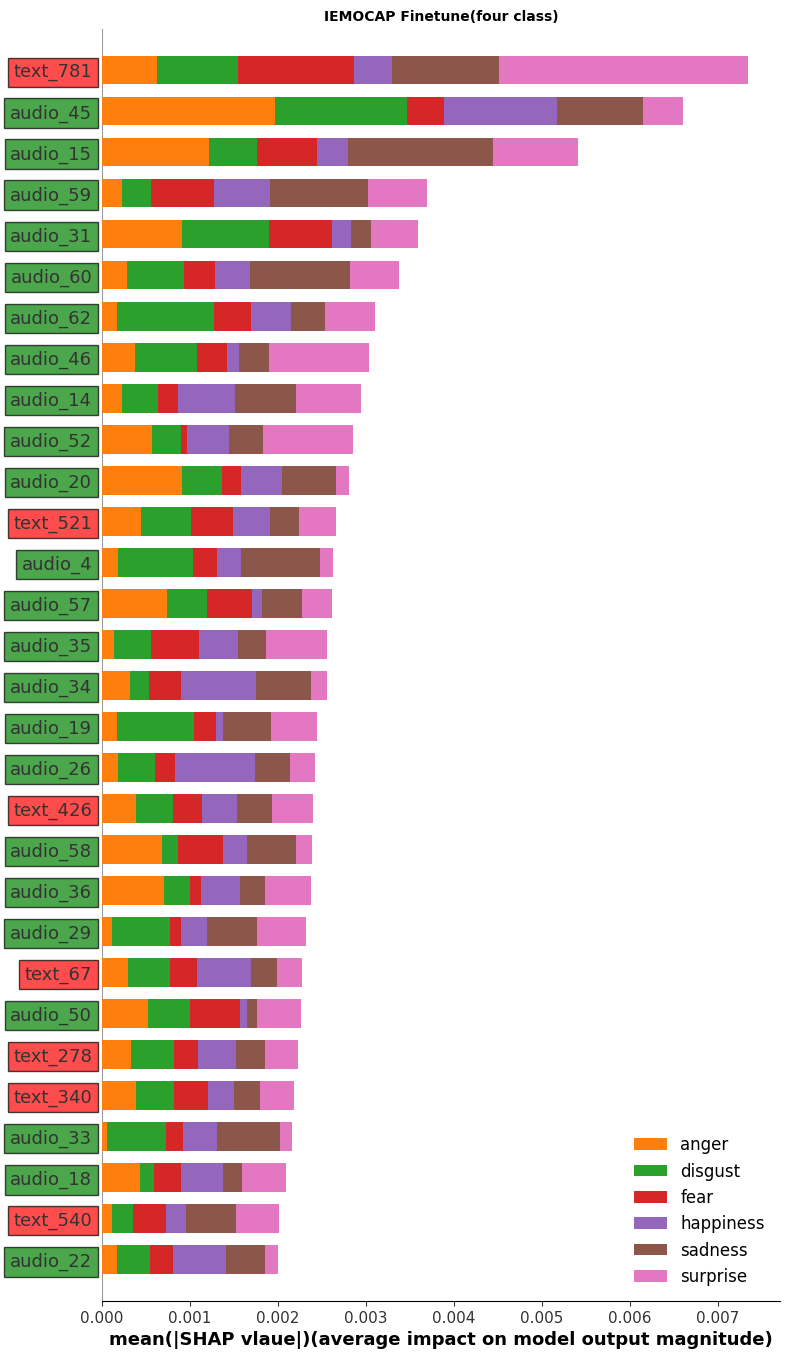

In [63]:
import matplotlib.pyplot as plt
import matplotlib
x_feature_names = ['text_' + str(i) for i in range(1024)] + ['video_' + str(i) for i in range(64)] + ['audio_' + str(i) for i in range(64)]

colors = matplotlib.colors.ListedColormap(plt.cm.tab10.colors[1:7])
shap.summary_plot(shap_values, class_names=['anger', 'disgust', 'fear', 'happiness', 'sadness', 'surprise'],\
                  color=colors, feature_names=x_feature_names, show=False, class_inds='original', sort=True, max_display=30)
# shap.summary_plot(shap_values, test, class_names=['anger', 'happiness', 'sadness', 'surprise'],\
#                   color=colors, feature_names=x_feature_names, show=False, class_inds='original', sort=True, max_display=30)
# labels = plt.gca().get_yticklabels()
yticklabels = plt.yticks()[1]
for label in yticklabels:
    if label.get_text()[:4] == 'text':
        label.set_bbox({'facecolor': 'red', 'alpha': 0.7})
    elif label.get_text()[:5] == 'video':
        label.set_bbox({'facecolor': 'blue', 'alpha': 0.5})
    elif label.get_text()[:5] == 'audio':
        label.set_bbox({'facecolor': 'green', 'alpha': 0.7})
# print(labels)
plt.title('IEMOCAP Finetune(four class)',fontsize=15,fontproperties="DejaVu Sans",weight='bold')
# plt.title('pretraining without eNTERFACE’05',fontsize=15,fontproperties="DejaVu Sans",weight='bold')
# plt.title('pretraining without IEMOCAP(four class)',fontsize=15,fontproperties="DejaVu Sans",weight='bold')
plt.xlabel('mean(|SHAP value|)(average impact on model output magnitude)',fontsize=13,fontproperties="DejaVu Sans",weight='bold')
# plt.savefig('/home/matt/Final_result/Class Imbalance/SHAP/SHAP_plot_1152/summary_plot.png', bbox_inches='tight')
plt.show()

In [64]:
for i in range(6):
    text = np.sum(np.abs(shap_values[i][:, :1024]), axis=1)  # text
    video = np.sum(np.abs(shap_values[i][:, 1024:1088]), axis=1)  # video
    audio = np.sum(np.abs(shap_values[i][:, 1088:]), axis=1)  # audio
    # 將結果拼接成 (4112, 3)
    shap_values[i] = np.stack((text, video, audio), axis=1)

In [65]:
shap_values[0].shape

(253, 3)

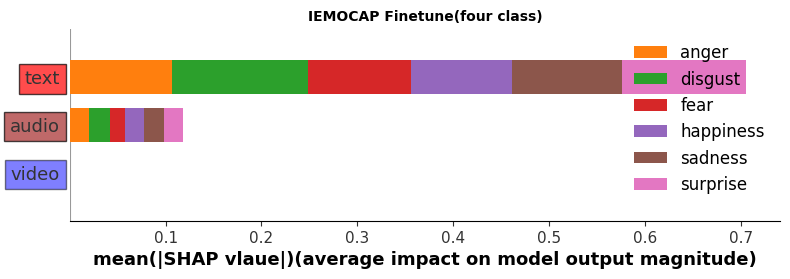

In [66]:
import matplotlib.pyplot as plt
import matplotlib

x_feature_names = ['text', 'video', 'audio']

colors = matplotlib.colors.ListedColormap(plt.cm.tab10.colors[1:7])

shap.summary_plot(shap_values, class_names=['anger', 'disgust', 'fear', 'happiness', 'sadness', 'surprise'],\
                  color=colors, feature_names=x_feature_names, show=False, class_inds='original', sort=True)
# shap.summary_plot(shap_values, class_names=['anger', 'happiness', 'sadness', 'surprise'],\
#                   color=colors, feature_names=x_feature_names, show=False, class_inds='original', sort=True, max_display=30)

# labels = plt.gca().get_yticklabels()
yticklabels = plt.yticks()[1]
for label in yticklabels:
    if label.get_text() == 'text':
        label.set_bbox({'facecolor': 'red', 'alpha': 0.7})
    elif label.get_text() == 'video':
        label.set_bbox({'facecolor': 'blue', 'alpha': 0.5})
    elif label.get_text() == 'audio':
        label.set_bbox({'facecolor': 'brown', 'alpha': 0.7})
# print(labels)
plt.title('IEMOCAP Finetune(four class)',fontsize=15,fontproperties="DejaVu Sans",weight='bold')
# plt.title('pretraining without eNTERFACE’05',fontsize=15,fontproperties="DejaVu Sans",weight='bold')
# plt.title('pretraining without IEMOCAP(four class)',fontsize=15,fontproperties="DejaVu Sans",weight='bold')
plt.xlabel('mean(|SHAP value|)(average impact on model output magnitude)',fontsize=13,fontproperties="DejaVu Sans",weight='bold')
# plt.savefig('/home/matt/Final_result/Class Imbalance/SHAP/SHAP_plot_3/summary_plot.png', bbox_inches='tight')
# plt.savefig('/home/matt/Pictures/summary_plot.png', bbox_inches='tight')
plt.show()